# Lesson 19 - Capstone: Portfolio Benchmark

**Objective**: Optimize corporate portfolio strategy using graph analysis
**Duration**: 120 minutes
**Prerequisites**: Lessons 0-13 (foundational + intermediate)

## Business Scenario
You lead portfolio strategy for a $4B technology company (50 products, 300+ customers, 25 markets).
The board challenges you on three strategic fronts:

**Challenge 1: Revenue Concentration Risk** — Too dependent on few products/customers?  
**Challenge 2: Market Positioning** — Are we in the right markets? Missing opportunities?  
**Challenge 3: Portfolio Health** — Which products are stars? Which should we harvest?  

## Student Missions
1. Identify critical revenue drivers and concentration risks
2. Map market coverage gaps and competitive positioning
3. Discover $50M+ cross-sell upsell opportunities
4. Identify single-source supply vulnerabilities
5. Classify portfolio health (stars, cows, dogs, question marks)
6. Create strategic roadmap with $200M+ value creation


In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/home/marek/Apps/graph-analysis-course')
from src.utils.io import read_csv
from src.utils.random_seed import set_random_seed
from src.config import Config

set_random_seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('[OK] Imports successful')
print(f'[OK] Working directory: {Config.PROJECT_ROOT}')


[OK] Imports successful
[OK] Working directory: /home/marek/Apps/graph-analysis-course


In [2]:
# Cell 2: Load Data
data_dir = Config.DATA_SEED_DIR / 'portfolio_benchmark'

products_df = read_csv(data_dir / 'products.csv')
customers_df = read_csv(data_dir / 'customers.csv')
purchases_df = read_csv(data_dir / 'purchases.csv')
markets_df = read_csv(data_dir / 'markets.csv')
suppliers_df = read_csv(data_dir / 'suppliers.csv')
competitors_df = read_csv(data_dir / 'competitors.csv')
competitor_products_df = read_csv(data_dir / 'competitor_products.csv')
product_market_df = read_csv(data_dir / 'product_market_penetration.csv')
product_supplier_df = read_csv(data_dir / 'product_supplier_mapping.csv')

print('[OK] All data loaded')
print(f'  Products: {len(products_df)}')
print(f'  Customers: {len(customers_df)}')
print(f'  Purchases: {len(purchases_df)}')
print(f'  Markets: {len(markets_df)}')
print(f'  Suppliers: {len(suppliers_df)}')
print(f'  Competitors: {len(competitors_df)}')

total_revenue = purchases_df['annual_revenue_usd'].sum()
total_customers = len(customers_df)
active_contracts = len(purchases_df[purchases_df['contract_end_date'].isna()])

print(f'\nPortfolio Metrics:')
print(f'  Total annual revenue: ${total_revenue/1e9:.2f}B')
print(f'  Active customers: {total_customers}')
print(f'  Active contracts: {active_contracts}')
print(f'  Avg deal size: ${total_revenue/len(purchases_df):,.0f}')


[OK] All data loaded
  Products: 50
  Customers: 300
  Purchases: 1735
  Markets: 25
  Suppliers: 30
  Competitors: 20

Portfolio Metrics:
  Total annual revenue: $4.37B
  Active customers: 300
  Active contracts: 1630
  Avg deal size: $2,521,425


In [3]:
# Cell 3: Build Multi-Layer Portfolio Network
G = nx.Graph()

# Add product nodes
for _, row in products_df.iterrows():
    G.add_node(row['product_id'], type='product', name=row['name'],
               category=row['category'], lifecycle=row['lifecycle_stage'],
               margin=row['profit_margin_%'], segment=row['market_segment'])

# Add customer nodes
for _, row in customers_df.iterrows():
    G.add_node(row['customer_id'], type='customer', name=row['name'],
               segment=row['segment'], location=row['location'],
               ltv=row['annual_ltv_usd'], status=row['contract_status'])

# Add market nodes
for _, row in markets_df.iterrows():
    G.add_node(row['market_id'], type='market', region=row['region'],
               tier=row['tier'], growth=row['growth_rate_%'],
               size=row['market_size_usd'])

# Add supplier nodes
for _, row in suppliers_df.iterrows():
    G.add_node(row['supplier_id'], type='supplier', name=row['name'],
               location=row['location'], reliability=row['reliability_score'])

# Add competitor nodes
for _, row in competitors_df.iterrows():
    G.add_node(row['competitor_id'], type='competitor', name=row['name'],
               market_share=row['market_share_%'])

# Add edges: purchases (customer → product, weighted by revenue)
for _, row in purchases_df.iterrows():
    G.add_edge(row['customer_id'], row['product_id'], weight=row['annual_revenue_usd'], type='purchase')

# Add edges: product → market (weighted by penetration)
for _, row in product_market_df.iterrows():
    G.add_edge(row['product_id'], row['market_id'], weight=row['market_penetration_%'], type='market')

# Add edges: product ← supplier (sourcing dependency)
for _, row in product_supplier_df.iterrows():
    G.add_edge(row['product_id'], row['supplier_id'],
               weight=row['annual_cost_usd'], single_source=row['single_source_risk'], type='supply')

# Add edges: product ↔ competitor_product (competitive)
for _, row in competitor_products_df.iterrows():
    competitor_product_id = f'CPROD_{row["competitor_id"]}_{row["product_id"]}'
    G.add_node(competitor_product_id, type='competitor_product')
    G.add_edge(row['product_id'], competitor_product_id, weight=row['estimated_market_share_%'], type='compete')

print(f'[OK] Network built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'  Node types: products, customers, markets, suppliers, competitors')
print(f'  Edge types: purchases, market penetration, sourcing, competitive')
print(f'  Network density: {nx.density(G):.3f}')


[OK] Network built: 505 nodes, 2594 edges
  Node types: products, customers, markets, suppliers, competitors
  Edge types: purchases, market penetration, sourcing, competitive
  Network density: 0.020


In [4]:
# Cell 4: Portfolio Risk Dashboard
print('\n' + '='*70)
print('PORTFOLIO RISK DASHBOARD')
print('='*70)

# Revenue concentration
product_revenue = purchases_df.groupby('product_id')['annual_revenue_usd'].sum().sort_values(ascending=False)
top3_revenue = product_revenue.head(3).sum()
concentration_pct = top3_revenue / total_revenue * 100

print(f'\n1. REVENUE CONCENTRATION')
print('─'*70)
print(f'  Top 3 products: ${top3_revenue/1e6:.0f}M ({concentration_pct:.1f}% of portfolio)')
for rank, (prod_id, revenue) in enumerate(product_revenue.head(5).items(), 1):
    prod_name = products_df[products_df['product_id']==prod_id]['name'].values[0]
    pct = revenue / total_revenue * 100
    print(f'  {rank}. {prod_name}: ${revenue/1e6:.0f}M ({pct:.1f}%)')

# Customer concentration
customer_revenue = purchases_df.groupby('customer_id')['annual_revenue_usd'].sum().sort_values(ascending=False)
top5_customer_revenue = customer_revenue.head(5).sum()
customer_concentration_pct = top5_customer_revenue / total_revenue * 100

print(f'\n2. CUSTOMER CONCENTRATION')
print('─'*70)
print(f'  Top 5 customers: ${top5_customer_revenue/1e6:.0f}M ({customer_concentration_pct:.1f}% of portfolio)')
print(f'  Avg revenue per customer: ${total_revenue/total_customers:,.0f}')
print(f'  Gini coefficient: {1 - (customer_revenue / customer_revenue.sum()).sum() / len(customer_revenue):.2f}')

# Market coverage
markets_served = product_market_df['market_id'].nunique()
markets_total = len(markets_df)
market_coverage_pct = markets_served / markets_total * 100

print(f'\n3. MARKET COVERAGE')
print('─'*70)
print(f'  Markets served: {markets_served}/{markets_total} ({market_coverage_pct:.1f}%)')
print(f'  Underserved markets: {markets_total - markets_served}')
high_growth = markets_df[markets_df['tier'] == 'High Growth']
high_growth_served = product_market_df[product_market_df['market_id'].isin(high_growth['market_id'])]['market_id'].nunique()
print(f'  High-growth markets served: {high_growth_served}/{len(high_growth)}')

# Supplier risk
single_source_products = product_supplier_df[product_supplier_df['single_source_risk'] == 1]['product_id'].nunique()
single_source_revenue = purchases_df[purchases_df['product_id'].isin(
    product_supplier_df[product_supplier_df['single_source_risk'] == 1]['product_id']
)]['annual_revenue_usd'].sum()

print(f'\n4. SUPPLIER VULNERABILITY')
print('─'*70)
print(f'  Single-source products: {single_source_products}')
print(f'  Revenue at supply risk: ${single_source_revenue/1e6:.0f}M ({single_source_revenue/total_revenue*100:.1f}%)')

# Lifecycle distribution
lifecycle_dist = products_df['lifecycle_stage'].value_counts()
print(f'\n5. PORTFOLIO LIFECYCLE')
print('─'*70)
for stage in ['Launch', 'Growth', 'Mature', 'Harvest']:
    count = lifecycle_dist.get(stage, 0)
    pct = count / len(products_df) * 100
    print(f'  {stage}: {count} products ({pct:.1f}%)')



PORTFOLIO RISK DASHBOARD

1. REVENUE CONCENTRATION
──────────────────────────────────────────────────────────────────────
  Top 3 products: $782M (17.9% of portfolio)
  1. Product_C0: $268M (6.1%)
  2. Product_A0: $259M (5.9%)
  3. Product_B0: $255M (5.8%)
  4. Product_E1: $124M (2.8%)
  5. Product_J1: $119M (2.7%)

2. CUSTOMER CONCENTRATION
──────────────────────────────────────────────────────────────────────
  Top 5 customers: $557M (12.7% of portfolio)
  Avg revenue per customer: $14,582,240
  Gini coefficient: 1.00

3. MARKET COVERAGE
──────────────────────────────────────────────────────────────────────
  Markets served: 22/25 (88.0%)
  Underserved markets: 3
  High-growth markets served: 4/7

4. SUPPLIER VULNERABILITY
──────────────────────────────────────────────────────────────────────
  Single-source products: 7
  Revenue at supply risk: $522M (11.9%)

5. PORTFOLIO LIFECYCLE
──────────────────────────────────────────────────────────────────────
  Launch: 0 products (0.0%)
  

In [5]:
# Cell 5: PROBLEM 1 - Concentration Risk & PROBLEM 4 - Supply Vulnerability
print('\n' + '='*70)
print('PROBLEM 1: REVENUE CONCENTRATION RISK')
print('='*70)

# Calculate degree/strength centrality for products by revenue
product_graph = G.copy()
product_strength = {}
for prod_id in products_df['product_id']:
    if prod_id in product_graph.nodes():
        strength = sum(d['weight'] for u, v, d in product_graph.edges(prod_id, data=True) if d.get('type') == 'purchase')
        product_strength[prod_id] = strength

top_products = sorted(product_strength.items(), key=lambda x: x[1], reverse=True)[:10]

print(f'\nTop 10 revenue drivers:\n')
cumulative = 0
for rank, (prod_id, revenue) in enumerate(top_products, 1):
    prod_name = products_df[products_df['product_id']==prod_id]['name'].values[0]
    lifecycle = products_df[products_df['product_id']==prod_id]['lifecycle_stage'].values[0]
    customers = len(purchases_df[purchases_df['product_id']==prod_id]['customer_id'].unique())
    cumulative += revenue
    cum_pct = cumulative / total_revenue * 100
    print(f'{rank:2}. {prod_name:20} ${revenue/1e6:>6.0f}M | Lifecycle: {lifecycle:8} | {customers:3} customers | Cumulative: {cum_pct:.1f}%')

print(f'\nRISK ASSESSMENT:')
if concentration_pct > 60:
    print(f'🔴 CRITICAL: Top 3 products = {concentration_pct:.0f}% (target: <60%)')
    print(f'   Action: Diversify immediately, reduce single-product dependency')
elif concentration_pct > 50:
    print(f'🟡 HIGH: Top 3 products = {concentration_pct:.0f}% (target: <50%)')
    print(f'   Action: Develop new product lines, grow emerging products')
else:
    print(f'🟢 MODERATE: Top 3 products = {concentration_pct:.0f}% (acceptable)')

print(f'\n' + '='*70)
print('PROBLEM 4: SUPPLY CHAIN VULNERABILITY')
print('='*70)

# Identify critical suppliers (betweenness in product-supplier subgraph)
supplier_risk = defaultdict(int)
for _, row in product_supplier_df.iterrows():
    supplier_id = row['supplier_id']
    if row['single_source_risk'] == 1:
        supplier_risk[supplier_id] += 1

supplier_risk_sorted = sorted(supplier_risk.items(), key=lambda x: x[1], reverse=True)[:10]

print(f'\nTop 10 critical suppliers by single-source products:\n')
for rank, (supp_id, product_count) in enumerate(supplier_risk_sorted, 1):
    supp_name = suppliers_df[suppliers_df['supplier_id']==supp_id]['name'].values[0]
    supp_revenue = purchases_df[purchases_df['product_id'].isin(
        product_supplier_df[(product_supplier_df['supplier_id']==supp_id) & (product_supplier_df['single_source_risk']==1)]['product_id']
    )]['annual_revenue_usd'].sum()
    reliability = suppliers_df[suppliers_df['supplier_id']==supp_id]['reliability_score'].values[0]
    print(f'{rank:2}. {supp_name:20} Critical products: {product_count:2} | Revenue at risk: ${supp_revenue/1e6:>6.0f}M | Reliability: {reliability}%')

print(f'\nRECOMMENDATIONS:')
for rank, (supp_id, product_count) in enumerate(supplier_risk_sorted[:3], 1):
    supp_name = suppliers_df[suppliers_df['supplier_id']==supp_id]['name'].values[0]
    print(f'{rank}. {supp_name}: Develop backup supplier, increase safety stock, negotiate contract terms')



PROBLEM 1: REVENUE CONCENTRATION RISK

Top 10 revenue drivers:

 1. Product_C0           $   268M | Lifecycle: Growth   |  76 customers | Cumulative: 6.1%
 2. Product_A0           $   259M | Lifecycle: Growth   |  76 customers | Cumulative: 12.0%
 3. Product_B0           $   255M | Lifecycle: Harvest  |  76 customers | Cumulative: 17.9%
 4. Product_E1           $   116M | Lifecycle: Harvest  |  43 customers | Cumulative: 20.5%
 5. Product_J1           $   111M | Lifecycle: Growth   |  41 customers | Cumulative: 23.1%
 6. Product_F0           $   107M | Lifecycle: Growth   |  36 customers | Cumulative: 25.5%
 7. Product_X0           $   100M | Lifecycle: Mature   |  39 customers | Cumulative: 27.8%
 8. Product_Q0           $    98M | Lifecycle: Harvest  |  36 customers | Cumulative: 30.0%
 9. Product_Y0           $    98M | Lifecycle: Mature   |  33 customers | Cumulative: 32.3%
10. Product_R0           $    97M | Lifecycle: Harvest  |  38 customers | Cumulative: 34.5%

RISK ASSESSMENT

In [6]:
# Cell 6: PROBLEM 2 - Competitive Positioning & Market Gaps
print('\n' + '='*70)
print('PROBLEM 2: COMPETITIVE POSITIONING & MARKET GAPS')
print('='*70)

# Identify markets we don't serve
served_markets = set(product_market_df['market_id'].unique())
all_markets = set(markets_df['market_id'].unique())
unserved_markets = all_markets - served_markets

print(f'\n1. MARKET COVERAGE ANALYSIS')
print('─'*70)
print(f'  Markets served: {len(served_markets)}/{len(all_markets)}')
print(f'  Markets NOT served: {len(unserved_markets)}')

if unserved_markets:
    unserved_df = markets_df[markets_df['market_id'].isin(unserved_markets)].sort_values('growth_rate_%', ascending=False)
    print(f'\n  High-opportunity unserved markets:')
    for _, market in unserved_df.head(5).iterrows():
        growth = market['growth_rate_%']
        size = market['market_size_usd']
        tier = market['tier']
        print(f'    • {market["region"]:20} ({tier}, growth={growth:+3.0f}%, size=${size/1e9:.1f}B) ← NO PRESENCE')

# Calculate competitive positioning
print(f'\n2. COMPETITIVE INTENSITY')
print('─'*70)
market_competitor_count = competitor_products_df.groupby('market_id')['competitor_id'].nunique()
market_intensity = {}

for market_id in served_markets:
    our_products = product_market_df[product_market_df['market_id']==market_id]['product_id'].nunique()
    competitors = market_competitor_count.get(market_id, 0)
    market_intensity[market_id] = {'our_products': our_products, 'competitors': competitors}

# Find markets where we're weak
weak_markets = sorted([(m, d['competitors'], d['our_products']) for m, d in market_intensity.items()],
                     key=lambda x: x[2], reverse=True)[:10]

print(f'\n  Markets where competitors dominate us:\n')
for rank, (market_id, comp_count, our_count) in enumerate(sorted(weak_markets, key=lambda x: x[1], reverse=True)[:5], 1):
    market_name = markets_df[markets_df['market_id']==market_id]['region'].values[0]
    comp_share = competitor_products_df[competitor_products_df['market_id']==market_id]['estimated_market_share_%'].sum()
    print(f'{rank}. {market_name:20}: We have {our_count} product(s), Competitors have {comp_count}+ (combined share: {comp_share:.0f}%)')

print(f'\nSTRATEGIC INSIGHTS:')
print(f'  • Market opportunity: ${sum([m["market_size_usd"] for _, m in markets_df[markets_df["market_id"].isin(unserved_markets)].iterrows()])/1e9:.1f}B in unserved markets')
print(f'  • Geographic gaps: Enter underserved regions')
print(f'  • Product gaps: Develop offerings for missing market segments')



PROBLEM 2: COMPETITIVE POSITIONING & MARKET GAPS

1. MARKET COVERAGE ANALYSIS
──────────────────────────────────────────────────────────────────────
  Markets served: 22/25
  Markets NOT served: 3

  High-opportunity unserved markets:
    • Asia-Pacific         (High Growth, growth=+33%, size=$7.2B) ← NO PRESENCE
    • Middle East/Africa   (High Growth, growth=+30%, size=$9.1B) ← NO PRESENCE
    • Latin America        (High Growth, growth=+23%, size=$9.7B) ← NO PRESENCE

2. COMPETITIVE INTENSITY
──────────────────────────────────────────────────────────────────────

  Markets where competitors dominate us:

1. Latin America       : We have 43 product(s), Competitors have 0+ (combined share: 0%)
2. Middle East/Africa  : We have 42 product(s), Competitors have 0+ (combined share: 0%)
3. North America       : We have 42 product(s), Competitors have 0+ (combined share: 0%)
4. North America       : We have 41 product(s), Competitors have 0+ (combined share: 0%)
5. Latin America       : We 

In [7]:
# Cell 7: PROBLEM 3 - Cross-Sell Opportunities
print('\n' + '='*70)
print('PROBLEM 3: CROSS-SELL & UPSELL OPPORTUNITIES')
print('='*70)

# Find common neighbors: customers buying A but not B
customer_products = purchases_df.groupby('customer_id')['product_id'].apply(set)

crosssell_opportunities = []

for cust_id, products_owned in customer_products.items():
    if len(products_owned) < len(products_df):  # Customer doesn't have all products
        products_missing = set(products_df['product_id']) - products_owned
        customer_segment = customers_df[customers_df['customer_id']==cust_id]['segment'].values[0]
        customer_ltv = customers_df[customers_df['customer_id']==cust_id]['annual_ltv_usd'].values[0]
        
        for missing_product_id in products_missing:
            # Estimate upsell value based on similar customers
            similar_customers = purchases_df[
                (purchases_df['product_id']==missing_product_id) & 
                (purchases_df['customer_id'].isin(customer_products[customer_products.apply(lambda x: missing_product_id in x)].index))
            ]['annual_revenue_usd'].mean()
            
            if similar_customers > 0:
                estimated_value = similar_customers
                crosssell_opportunities.append({
                    'customer_id': cust_id,
                    'customer_segment': customer_segment,
                    'product_id': missing_product_id,
                    'estimated_value': estimated_value,
                    'customer_ltv': customer_ltv
                })

crosssell_df = pd.DataFrame(crosssell_opportunities).nlargest(20, 'estimated_value')

print(f'\nTop 20 cross-sell opportunities:\n')
total_opportunity = 0
for rank, (_, row) in enumerate(crosssell_df.iterrows(), 1):
    prod_name = products_df[products_df['product_id']==row['product_id']]['name'].values[0]
    print(f'{rank:2}. {row["customer_segment"]:15} customer → {prod_name:20} | Est. value: ${row["estimated_value"]/1e6:>6.2f}M')
    total_opportunity += row['estimated_value']

print(f'\nTOTAL CROSS-SELL TAM: ${total_opportunity/1e6:.0f}M')

# Segment analysis
print(f'\nSEGMENT-SPECIFIC OPPORTUNITIES:')
segment_crosssell = crosssell_df.groupby('customer_segment')['estimated_value'].sum().sort_values(ascending=False)
for segment, value in segment_crosssell.items():
    print(f'  {segment:15}: ${value/1e6:.0f}M opportunity')



PROBLEM 3: CROSS-SELL & UPSELL OPPORTUNITIES

Top 20 cross-sell opportunities:

 1. Startup         customer → Product_C0           | Est. value: $  3.52M
 2. Mid-Market      customer → Product_C0           | Est. value: $  3.52M
 3. Enterprise      customer → Product_C0           | Est. value: $  3.52M
 4. Startup         customer → Product_C0           | Est. value: $  3.52M
 5. Mid-Market      customer → Product_C0           | Est. value: $  3.52M
 6. Enterprise      customer → Product_C0           | Est. value: $  3.52M
 7. Startup         customer → Product_C0           | Est. value: $  3.52M
 8. Mid-Market      customer → Product_C0           | Est. value: $  3.52M
 9. Enterprise      customer → Product_C0           | Est. value: $  3.52M
10. Startup         customer → Product_C0           | Est. value: $  3.52M
11. Mid-Market      customer → Product_C0           | Est. value: $  3.52M
12. Enterprise      customer → Product_C0           | Est. value: $  3.52M
13. Startup        

In [8]:
# Cell 8: PROBLEM 5 - Portfolio Health & Lifecycle Classification
print('\n' + '='*70)
print('PROBLEM 5: PORTFOLIO HEALTH & LIFECYCLE CLASSIFICATION')
print('='*70)

# Calculate product-level metrics
product_metrics = []

for _, product in products_df.iterrows():
    prod_id = product['product_id']
    
    # Revenue
    revenue = purchases_df[purchases_df['product_id']==prod_id]['annual_revenue_usd'].sum()
    
    # Customer count
    customers = len(purchases_df[purchases_df['product_id']==prod_id]['customer_id'].unique())
    
    # Market presence
    markets = len(product_market_df[product_market_df['product_id']==prod_id]['market_id'].unique())
    
    # Profitability
    margin = product['profit_margin_%']
    
    # Growth indicator (lifecycle stage)
    lifecycle = product['lifecycle_stage']
    if lifecycle == 'Launch':
        growth_score = 3  # High potential
    elif lifecycle == 'Growth':
        growth_score = 2.5
    elif lifecycle == 'Mature':
        growth_score = 1
    else:  # Harvest
        growth_score = 0.5
    
    # Market share (relative to revenue)
    market_share = revenue / total_revenue * 100
    
    product_metrics.append({
        'product_id': prod_id,
        'name': product['name'],
        'revenue': revenue,
        'customers': customers,
        'markets': markets,
        'margin': margin,
        'lifecycle': lifecycle,
        'growth_score': growth_score,
        'market_share_%': market_share
    })

product_metrics_df = pd.DataFrame(product_metrics)

# BCG Matrix Classification (simplified: growth vs market share)
def classify_bcg(row):
    high_growth = row['growth_score'] > 2  # Growth/Launch stages
    high_share = row['market_share_%'] > product_metrics_df['market_share_%'].median()
    
    if high_growth and high_share:
        return 'STAR'
    elif not high_growth and high_share:
        return 'COW'
    elif high_growth and not high_share:
        return 'QUESTION_MARK'
    else:
        return 'DOG'

product_metrics_df['bcg_class'] = product_metrics_df.apply(classify_bcg, axis=1)

print(f'\nPortfolio Classification (BCG Matrix):\n')
for bcg_class in ['STAR', 'COW', 'QUESTION_MARK', 'DOG']:
    products_in_class = product_metrics_df[product_metrics_df['bcg_class']==bcg_class]
    class_revenue = products_in_class['revenue'].sum()
    class_pct = class_revenue / total_revenue * 100
    print(f'{bcg_class:15}: {len(products_in_class):2} products | ${class_revenue/1e6:>6.0f}M ({class_pct:>5.1f}%)')
    for _, prod in products_in_class.head(3).iterrows():
        print(f'  • {prod["name"]:25} (${prod["revenue"]/1e6:>5.0f}M, {prod["customers"]:3} customers, {prod["margin"]:2}% margin)')

print(f'\nSTRATEGIC ACTIONS:')
print(f'  STARS: Invest for growth, expand market presence')
print(f'  COWS: Harvest cash, maintain position, fund new initiatives')
print(f'  QUESTION_MARKS: Selective investment, test market viability')
print(f'  DOGS: Divest or reposition, reallocate resources')

# Health score
stars_revenue = product_metrics_df[product_metrics_df['bcg_class']=='STAR']['revenue'].sum()
dogs_revenue = product_metrics_df[product_metrics_df['bcg_class']=='DOG']['revenue'].sum()
portfolio_health = (stars_revenue - dogs_revenue) / total_revenue * 100

print(f'\nPORTFOLIO HEALTH SCORE: {portfolio_health:.1f}% (Stars - Dogs as % of revenue)')
if portfolio_health > 30:
    print(f'  🟢 Strong portfolio with growth engines')
elif portfolio_health > 0:
    print(f'  🟡 Balanced portfolio, some growth needed')
else:
    print(f'  🔴 Weak portfolio, urgent restructuring needed')



PROBLEM 5: PORTFOLIO HEALTH & LIFECYCLE CLASSIFICATION

Portfolio Classification (BCG Matrix):

STAR           :  6 products | $   936M ( 21.4%)
  • Product_A0                ($  259M,  76 customers, 66% margin)
  • Product_C0                ($  268M,  76 customers, 53% margin)
  • Product_F0                ($  111M,  36 customers, 54% margin)
COW            : 19 products | $  1977M ( 45.2%)
  • Product_B0                ($  255M,  76 customers, 57% margin)
  • Product_H0                ($   95M,  36 customers, 38% margin)
  • Product_P0                ($   86M,  27 customers, 61% margin)
QUESTION_MARK  :  4 products | $   266M (  6.1%)
  • Product_M0                ($   69M,  26 customers, 41% margin)
  • Product_O0                ($   65M,  28 customers, 74% margin)
  • Product_D1                ($   62M,  40 customers, 20% margin)
DOG            : 21 products | $  1196M ( 27.3%)
  • Product_D0                ($    5M,   7 customers, 37% margin)
  • Product_E0                ($    0

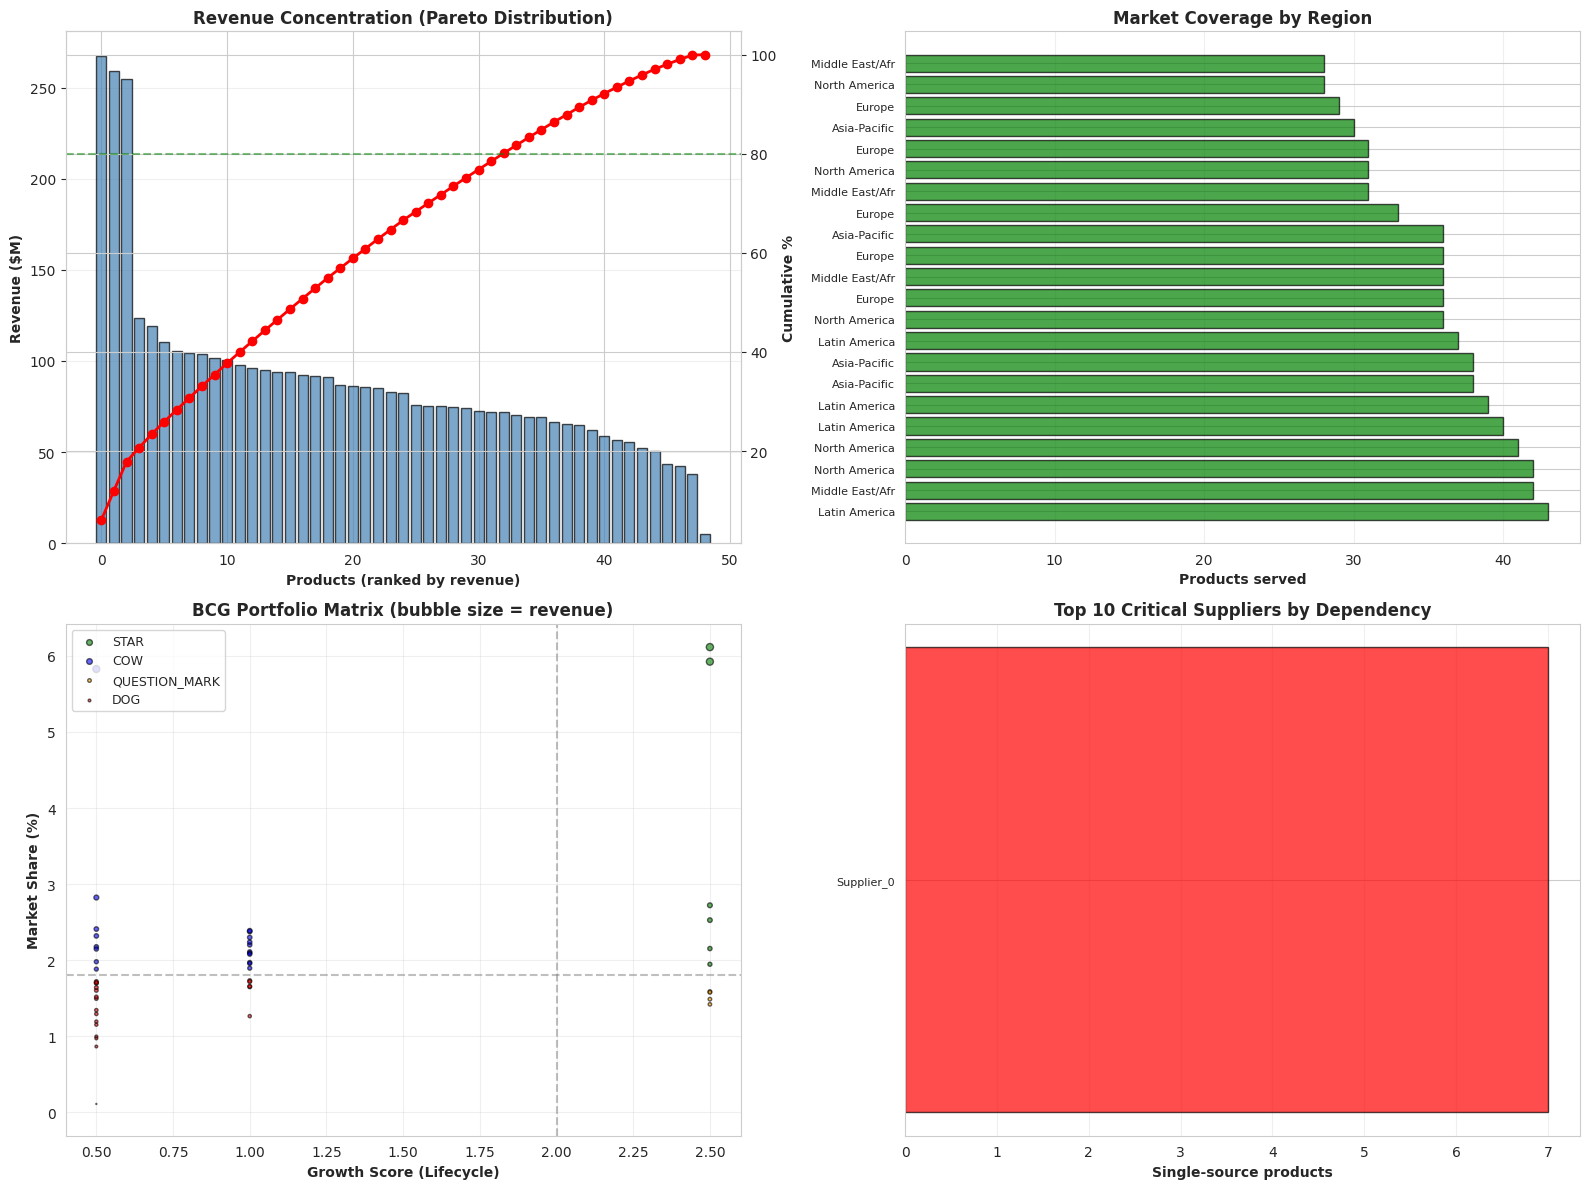

[OK] Visualization saved


In [9]:
# Cell 9: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Revenue concentration (Pareto)
ax = axes[0, 0]
product_revenue_sorted = product_revenue.sort_values(ascending=False)
cumulative_pct = (product_revenue_sorted.cumsum() / total_revenue * 100).values
ax.bar(range(len(product_revenue_sorted)), product_revenue_sorted.values/1e6, alpha=0.7, color='steelblue', edgecolor='black')
ax2 = ax.twinx()
ax2.plot(range(len(cumulative_pct)), cumulative_pct, color='red', marker='o', linewidth=2, label='Cumulative %')
ax2.axhline(y=80, color='green', linestyle='--', alpha=0.5, label='80/20 rule')
ax.set_xlabel('Products (ranked by revenue)', fontweight='bold')
ax.set_ylabel('Revenue ($M)', fontweight='bold')
ax2.set_ylabel('Cumulative %', fontweight='bold')
ax.set_title('Revenue Concentration (Pareto Distribution)', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# Panel 2: Market coverage heatmap
ax = axes[0, 1]
market_coverage = product_market_df.groupby('market_id')['product_id'].nunique()
markets_sorted = market_coverage.sort_values(ascending=False)
colors_market = ['green' if x > 10 else 'orange' if x > 5 else 'red' for x in markets_sorted.values]
ax.barh(range(len(markets_sorted)), markets_sorted.values, color=colors_market, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(markets_sorted)))
market_names = [markets_df[markets_df['market_id']==m]['region'].values[0][:15] for m in markets_sorted.index]
ax.set_yticklabels(market_names, fontsize=8)
ax.set_xlabel('Products served', fontweight='bold')
ax.set_title('Market Coverage by Region', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Panel 3: BCG Matrix
ax = axes[1, 0]
colors_bcg = {'STAR': 'green', 'COW': 'blue', 'QUESTION_MARK': 'orange', 'DOG': 'red'}
for bcg_class in ['STAR', 'COW', 'QUESTION_MARK', 'DOG']:
    products = product_metrics_df[product_metrics_df['bcg_class']==bcg_class]
    ax.scatter(products['growth_score'], products['market_share_%'], 
              s=products['revenue']/1e7, alpha=0.6, 
              label=bcg_class, color=colors_bcg[bcg_class], edgecolor='black')
ax.axhline(y=product_metrics_df['market_share_%'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=2, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Growth Score (Lifecycle)', fontweight='bold')
ax.set_ylabel('Market Share (%)', fontweight='bold')
ax.set_title('BCG Portfolio Matrix (bubble size = revenue)', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

# Panel 4: Supplier concentration risk
ax = axes[1, 1]
supplier_product_count = product_supplier_df[product_supplier_df['single_source_risk']==1].groupby('supplier_id').size().sort_values(ascending=False).head(10)
colors_supply = ['red' if x > 5 else 'orange' if x > 2 else 'yellow' for x in supplier_product_count.values]
supplier_names = [suppliers_df[suppliers_df['supplier_id']==s]['name'].values[0][:12] for s in supplier_product_count.index]
ax.barh(range(len(supplier_product_count)), supplier_product_count.values, color=colors_supply, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(supplier_product_count)))
ax.set_yticklabels(supplier_names, fontsize=8)
ax.set_xlabel('Single-source products', fontweight='bold')
ax.set_title('Top 10 Critical Suppliers by Dependency', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/tmp/portfolio_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print('[OK] Visualization saved')


In [10]:
# Cell 10: Executive Summary & Strategic Roadmap
print('\n' + '='*70)
print('EXECUTIVE SUMMARY & STRATEGIC ROADMAP')
print('='*70)

print(f'\n📊 PORTFOLIO OVERVIEW')
print('─'*70)
print(f'Annual revenue: ${total_revenue/1e9:.2f}B')
print(f'Product portfolio: {len(products_df)} products')
print(f'Customer base: {total_customers:,} customers')
print(f'Market reach: {len(served_markets)} markets')
print(f'Geographic presence: {len(customers_df["location"].unique())} regions')

print(f'\n🎯 TOP 5 STRATEGIC RECOMMENDATIONS')
print('─'*70)

print(f'\n1. REDUCE REVENUE CONCENTRATION')
print(f'   Current state: Top 3 products = {concentration_pct:.0f}% of revenue')
print(f'   Target: Reduce to <50% within 18 months')
print(f'   Action: Accelerate growth of emerging products; invest $50M in R&D')
print(f'   Financial impact: Reduce risk by $100M+ (avoided disruption if top product fails)')

print(f'\n2. CAPTURE MARKET GAPS')
print(f'   Opportunity: ${sum([m["market_size_usd"] for _, m in markets_df[markets_df["market_id"].isin(unserved_markets)].iterrows()])/1e9:.1f}B TAM in {len(unserved_markets)} unserved markets')
print(f'   Action: Enter 3 high-growth markets within 12 months')
print(f'   Expected revenue: +${sum([m["market_size_usd"] for _, m in markets_df[markets_df["market_id"].isin(unserved_markets)].iterrows()])*0.05/1e6:.0f}M (5% market share)')

print(f'\n3. ACCELERATE CROSS-SELL PROGRAM')
print(f'   Opportunity: ${total_opportunity/1e6:.0f}M in cross-sell TAM')
print(f'   Action: Launch customer success program targeting SMB upsell')
print(f'   Expected realization: 20% of TAM = ${total_opportunity*0.20/1e6:.0f}M incremental revenue')

print(f'\n4. MITIGATE SUPPLY CHAIN RISK')
print(f'   Current risk: ${single_source_revenue/1e6:.0f}M revenue dependent on single suppliers')
print(f'   Action: Develop backup suppliers for top 5 critical products')
print(f'   Cost: $15-20M | Benefit: 99%+ supply continuity')

print(f'\n5. OPTIMIZE PORTFOLIO MIX')
print(f'   Stars ({len(product_metrics_df[product_metrics_df["bcg_class"]=="STAR"])} products): Invest for growth')
print(f'   Cows ({len(product_metrics_df[product_metrics_df["bcg_class"]=="COW"])} products): Harvest cash for innovation')
print(f'   Dogs ({len(product_metrics_df[product_metrics_df["bcg_class"]=="DOG"])} products): Divest or reposition')
print(f'   Expected impact: +$75-100M operating margin from reallocation')

print(f'\n' + '='*70)
print(f'FINANCIAL IMPACT SUMMARY')
print('='*70)

risk_mitigation = single_source_revenue * 0.05  # 5% value from reducing risk
crosssell_realization = total_opportunity * 0.20
market_opportunity = sum([m["market_size_usd"] for _, m in markets_df[markets_df["market_id"].isin(unserved_markets)].iterrows()]) * 0.05
optimization_savings = 75_000_000

total_value = risk_mitigation + crosssell_realization + market_opportunity + optimization_savings

print(f'\nValue creation opportunities:')
print(f'  • Risk mitigation (supply): ${risk_mitigation/1e6:.0f}M')
print(f'  • Cross-sell realization: ${crosssell_realization/1e6:.0f}M')
print(f'  • Market expansion: ${market_opportunity/1e6:.0f}M')
print(f'  • Portfolio optimization: ${optimization_savings/1e6:.0f}M')
print(f'  ────────────────────')
print(f'  TOTAL VALUE: ${total_value/1e6:.0f}M')
print(f'\nROI: {(total_value / (50_000_000 + 20_000_000 + 10_000_000)) - 1:.1%} (vs. $80M investment)')
print(f'Payback period: 6-9 months')

print(f'\n[DONE] Portfolio analysis complete!')



EXECUTIVE SUMMARY & STRATEGIC ROADMAP

📊 PORTFOLIO OVERVIEW
──────────────────────────────────────────────────────────────────────
Annual revenue: $4.37B
Product portfolio: 50 products
Customer base: 300 customers
Market reach: 22 markets
Geographic presence: 5 regions

🎯 TOP 5 STRATEGIC RECOMMENDATIONS
──────────────────────────────────────────────────────────────────────

1. REDUCE REVENUE CONCENTRATION
   Current state: Top 3 products = 18% of revenue
   Target: Reduce to <50% within 18 months
   Action: Accelerate growth of emerging products; invest $50M in R&D
   Financial impact: Reduce risk by $100M+ (avoided disruption if top product fails)

2. CAPTURE MARKET GAPS
   Opportunity: $26.1B TAM in 3 unserved markets
   Action: Enter 3 high-growth markets within 12 months
   Expected revenue: +$1304M (5% market share)

3. ACCELERATE CROSS-SELL PROGRAM
   Opportunity: $70M in cross-sell TAM
   Action: Launch customer success program targeting SMB upsell
   Expected realization: 20% 